# Sergio Santamaría Trueba

## Segundo entrenamiento del lab 3. Limpieza de datos del archivo de vinos

Vamos a realizar la limpieza del archivo dataset.csv que contiene el dataset de vinos

In [9]:
# Importamos las librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Configuramos el estilo de Seaborn para mejor visualización
sns.set_theme(style="whitegrid")

In [10]:
# Carga de datos con ruta absoluta exigida
# CRÍTICO: Este dataset usa punto y coma como separador, no coma.
ruta_archivo = '/workspace/dataset.csv'
df = pd.read_csv(ruta_archivo, sep=';')

print("--- Información del DataFrame ---")
df.info()

print("\n--- Estadísticas Descriptivas ---")
display(df.describe())

--- Información del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB

--- Estadísticas Descriptiva

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


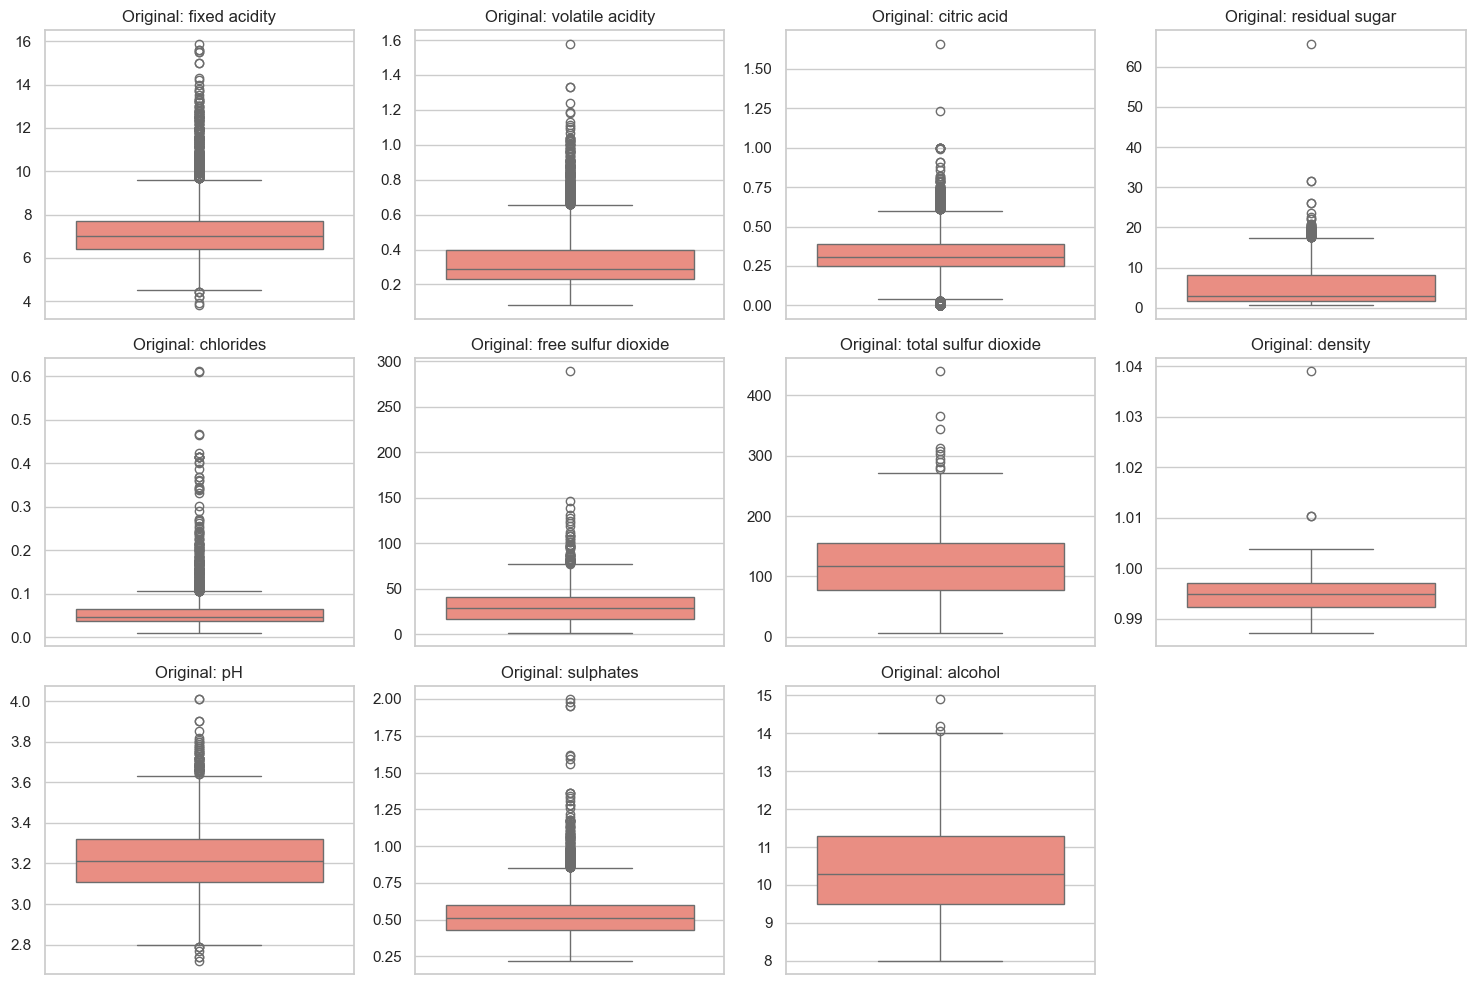

In [11]:
# Seleccionamos TODAS las columnas numéricas de forma universal (atrapa int32, int64, floats...)
columnas_numericas = df.select_dtypes(include='number').columns

# Quitamos 'quality' y usamos errors='ignore' para que no pete si ejecutas la celda varias veces
columnas_numericas = columnas_numericas.drop('quality', errors='ignore')

# Creamos boxplots para visualizar los valores atípicos (outliers) originales
plt.figure(figsize=(15, 10))
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[col], color='salmon')
    plt.title(f'Original: {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

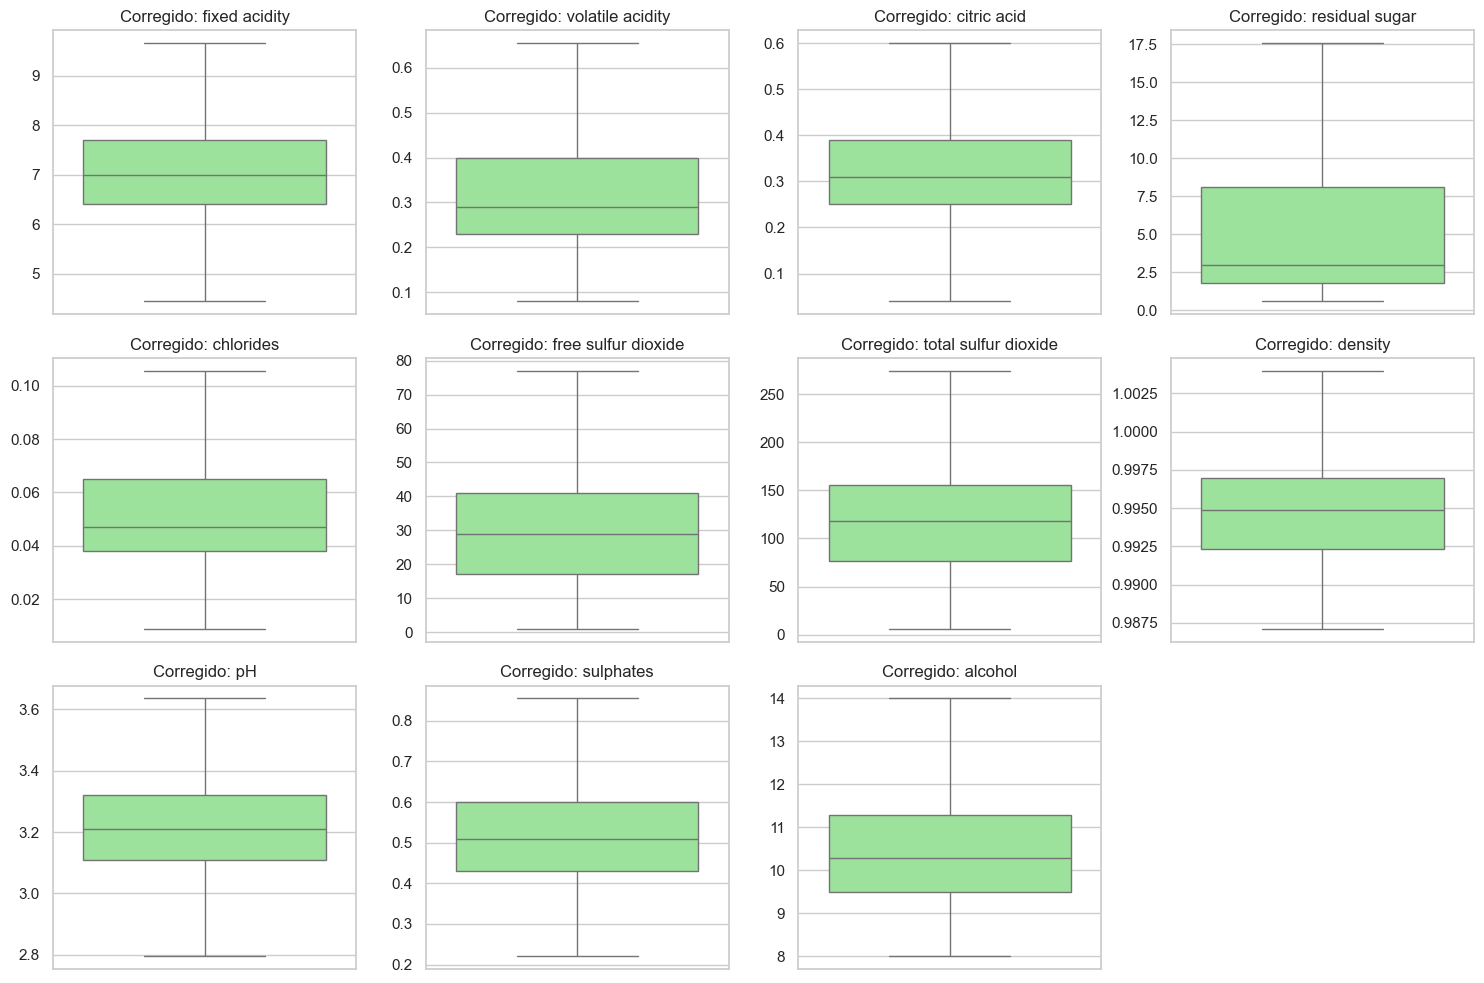

In [12]:
# Implementación del Rango Intercuartílico (IQR) 
for col in columnas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Documentación interna:
    # Todo valor por debajo del límite inferior se iguala al límite inferior.
    # Todo valor por encima del límite superior se iguala al límite superior.
    # La función clip() de pandas hace esto de forma impecable y directa.
    df[col] = df[col].clip(lower=limite_inferior, upper=limite_superior)

# Verificamos que la corrección haya sido exitosa con nuevos boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Corregido: {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [13]:


columnas_minmax = ['residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide']
columnas_standard = ['fixed acidity', 'volatile acidity', 'citric acid', 'density', 'pH', 'sulphates', 'alcohol']

# Instanciamos los escaladores de Scikit-learn
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

# Creamos una copia del dataframe para guardar los datos escalados y no destruir el original
df_scaled = df.copy()

# Aplicamos MinMaxScaler (los datos quedarán entre 0 y 1)
df_scaled[columnas_minmax] = minmax_scaler.fit_transform(df_scaled[columnas_minmax])

# Aplicamos StandardScaler (los datos quedarán con media 0 y desviación estándar 1)
df_scaled[columnas_standard] = standard_scaler.fit_transform(df_scaled[columnas_standard])

print("Datos escalados correctamente. Primeras filas:")
display(df_scaled.head())

Datos escalados correctamente. Primeras filas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,0.241864,2.233152,-2.094714,0.076696,0.694301,0.131579,0.104283,1.057459,1.851700,0.254091,-0.915758,5,red
1,0.617099,2.233152,-2.094714,0.117994,0.922280,0.315789,0.227188,0.717517,-0.111713,1.168825,-0.580200,5,red
2,0.617099,2.233152,-2.094714,0.100295,0.860104,0.184211,0.178771,0.785505,0.268303,0.940141,-0.580200,5,red
3,2.352562,-0.364438,1.849280,0.076696,0.683938,0.210526,0.201117,1.125447,-0.365056,0.406547,-0.580200,6,red
4,0.241864,2.233152,-2.094714,0.076696,0.694301,0.131579,0.104283,1.057459,1.851700,0.254091,-0.915758,5,red


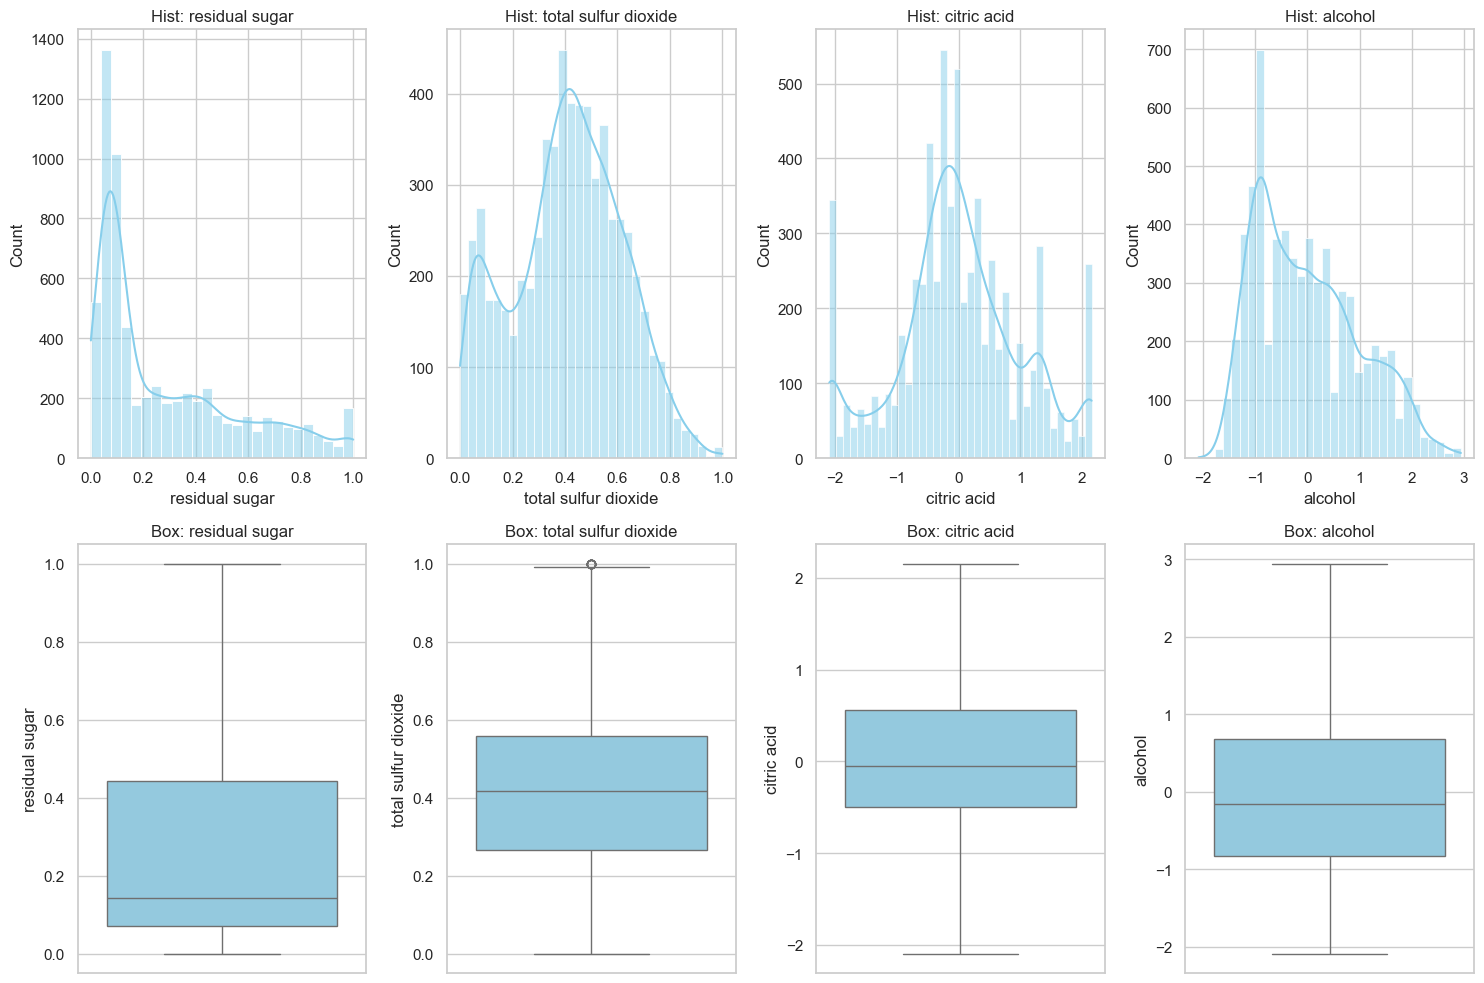

In [14]:


plt.figure(figsize=(15, 10))
# Mostramos un par de ejemplos representativos de cada escalado para demostrarlo
columnas_muestra = ['residual sugar', 'total sulfur dioxide', 'citric acid', 'alcohol']

for i, col in enumerate(columnas_muestra, 1):
    # Histograma
    plt.subplot(2, 4, i)
    sns.histplot(df_scaled[col], kde=True, color='skyblue')
    plt.title(f'Hist: {col}')
    
    # Boxplot
    plt.subplot(2, 4, i+4)
    sns.boxplot(y=df_scaled[col], color='skyblue')
    plt.title(f'Box: {col}')

plt.tight_layout()
plt.show()

In [15]:
# Guardamos los datos escalados 
ruta_salida = '/workspace/dataset_scaled.csv'
df_scaled.to_csv(ruta_salida, index=False, sep=';')

print(f"Los datos corregidos y escalados se han guardado exitosamente en: {ruta_salida}")

Los datos corregidos y escalados se han guardado exitosamente en: /workspace/dataset_scaled.csv
